# Dropout

### init

In [1]:
# Check for all needed packages
import time

import IPython
import matplotlib
import mnists
import numpy

# In case of ImportError, install them to the running kernel with
# %pip install numpy matplotlib mnists
# or the the runtime container with:
# !pip install numpy matplotlib mnists
# (In case of the latter, remember to restart the kernel!)

# Tested in Python 3.14.3 with:
# numpy==2.4.3
# matplotlib==3.10.8
# mnists==0.4.1

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(1234)

try:
    import mkl

    mkl.set_num_threads(2)
except ImportError:
    print(
        "Intel Math Kernel Library (MKL) does not always work on every machine. "
        "Continuing without `mkl`."
    )

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

Intel Math Kernel Library (MKL) does not always work on every machine. Continuing without `mkl`.


### Handy utility functions

In [3]:
def append_ones(matrix: np.ndarray, axis: int = 1) -> np.ndarray:
    """
    Appends a column of ones to the right side of a 2D matrix.
    """
    return np.concatenate(
        (matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=axis
    )


def zeros(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of zeros with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. zeros(3, 4) creates a (3, 4) array.
    """
    return np.zeros(shape=tuple(dims), dtype=np.float32)


def ones(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of ones with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. ones(3, 4) creates a (3, 4) array.
    """
    return np.ones(shape=tuple(dims), dtype=np.float32)


def rand(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a uniform [0, 1) distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.rand(*dims).astype(np.float32)


def randn(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a standard normal distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.randn(*dims).astype(np.float32)


def chunks(seq: list, size: int) -> tuple[np.ndarray]:
    """
    Splits a sequence into consecutive chunks of a given size.

    The last chunk may be smaller than `size` if the sequence length
    is not evenly divisible.

    Args:
        seq:  The input sequence (e.g. list or other sliceable) to split.
        size: The maximum number of elements in each chunk.

    Returns:
        Successive sub-sequences of length `size` (or less for the final chunk).
    """
    return tuple([seq[pos : (pos + size)] for pos in range(0, len(seq), size)])


def as_matrix(vector: np.ndarray) -> np.ndarray:
    """Reshape 1D vector to column matrix."""
    return np.reshape(vector, (-1, 1))


def one_hot_encode(labels: np.ndarray) -> np.ndarray:
    """Convert integer labels to one-hot encoded matrix."""
    (n_samples,) = labels.shape
    n_classes = np.max(labels) + 1

    one_hot = np.zeros((n_samples, n_classes), dtype=np.float32)
    one_hot[np.arange(n_samples), labels] = 1
    return one_hot


def classify(mlp: "MLP", batch: np.ndarray, forwad_pass_func: callable) -> np.ndarray:
    """
    Classify a batch of inputs using the MLP model.

    Performs a forward pass to compute class probabilities, then returns
    the predicted class indices (argmax over probabilities).

    Args:
        mlp: Trained MLP model with forward_pass method.
        batch: Input data batch of shape (N, input_dim).

    Returns:
        Predicted class indices of shape (N,).
    """
    # Shape: (batch_size, num_classes)
    probabilities, _ = forwad_pass_func(mlp, batch, False)
    predictions = np.argmax(probabilities, axis=1)
    return predictions


def arrange_tiles_img(examples: np.ndarray) -> np.ndarray:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(
        shape=(
            rows_count * (tile_height + space_between_tiles) - space_between_tiles,
            cols_count * (tile_width + space_between_tiles) - space_between_tiles,
        )
    )
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            img_matrix[x_0 : x_0 + tile_height, y_0 : y_0 + tile_width] = examples[r, c]

    return img_matrix


def preview_tiles(examples: np.ndarray) -> None:
    """Previews the arrange tiles"""
    img = arrange_tiles_img(examples)
    plt.matshow(img, cmap="gray", interpolation="none")
    plt.axis("off")
    plt.show()


def draw_rbm_filters(rbm: "RestrictedBoltzmannMachine") -> None:
    filters = np.reshape(np.transpose(rbm.W)[:-1, :-1], shape=(8, -1, 28, 28))
    preview_tiles(filters)


def draw_layer_filters(layer: "Layer") -> None:
    filters = np.reshape(layer.W[:-1].T, shape=(8, -1, 28, 28))
    preview_tiles(filters)

### Activation functions

In [ ]:
def sigmoid(batch: np.ndarray, stochastic: bool = False) -> np.ndarray:
    activations = 1.0 / (1.0 + np.exp(-batch))
    if stochastic:
        return activations > rand(*activations.shape).astype(np.float32)
    else:
        return activations


def sigmoid_derivative(batch):
    s = sigmoid(batch)
    return s * (1.0 - s)


def softmax(batch: np.ndarray) -> np.ndarray:
    # TODO implement (copy from previous labs)
    raise Exception("Not implemented!")

In [ ]:
def relu(batch: np.ndarray, stochastic: bool = False) -> np.ndarray:
    """
    Stochastic ReLU
    """
    # TODO implement (copy from previous labs)
    raise Exception("Not implemented!")


def relu_derivative(batch: np.ndarray) -> np.ndarray:
    """
    ReLU derivative
    """
    # TODO implement (copy from previous labs)
    raise Exception("Not implemented!")

# MNIST dataset

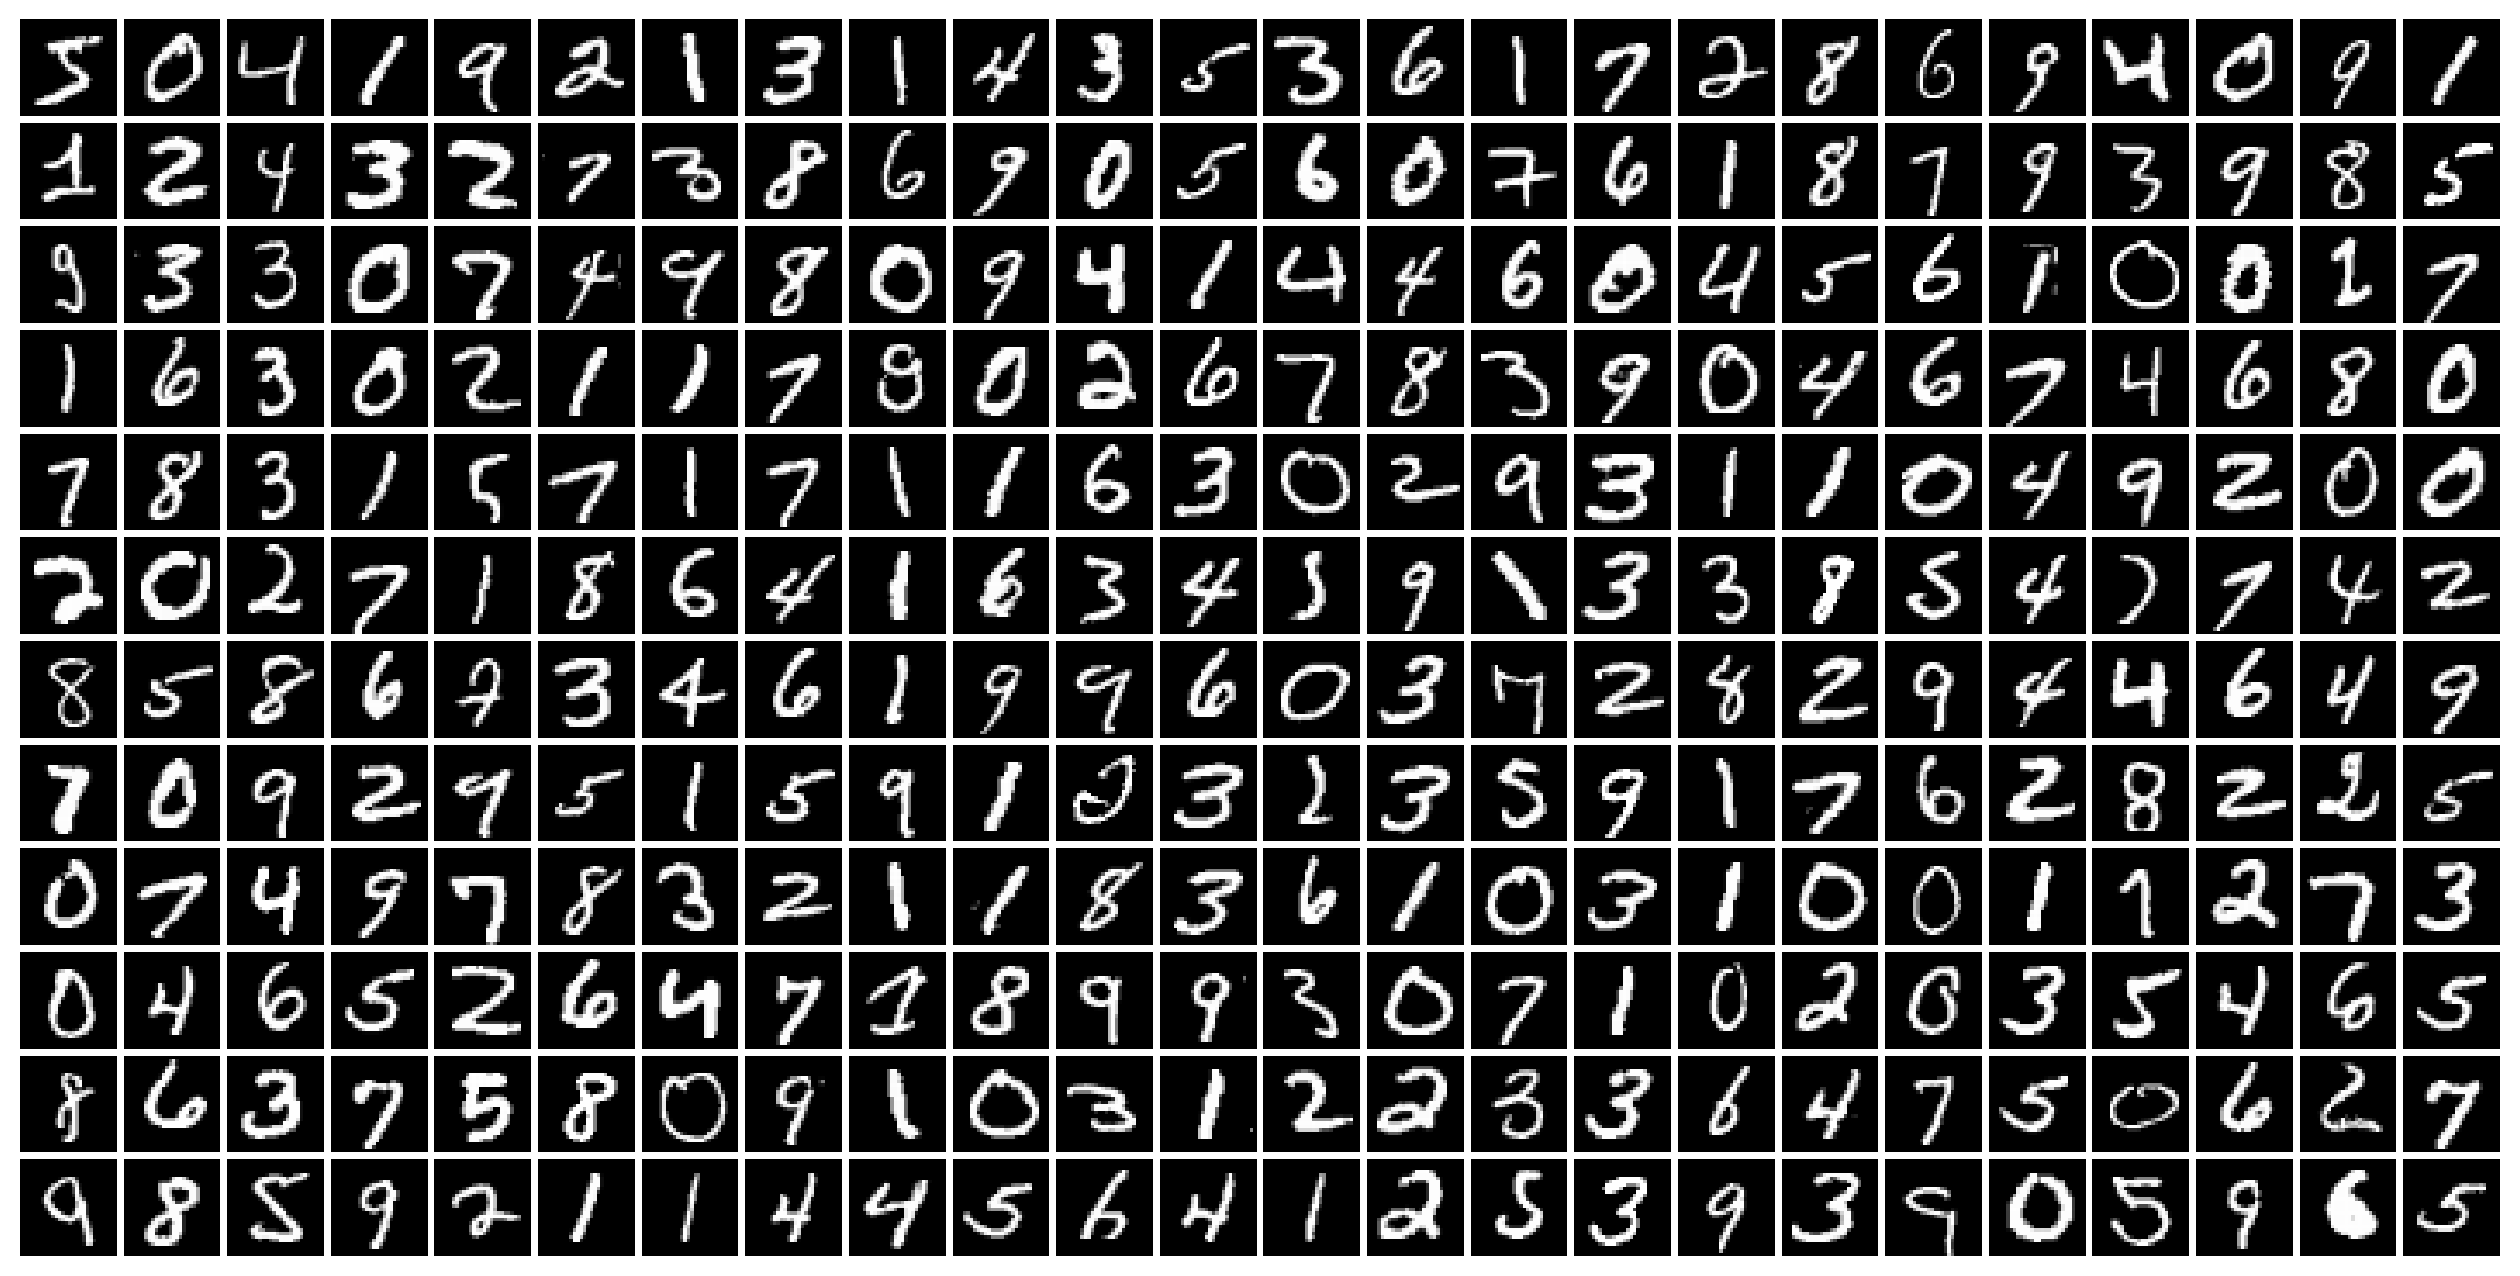

In [6]:
from mnists import MNIST

mnist = MNIST()

PREVIEW_N_ROWS = 12
PREVIEW_N_COLS = 24
TILE_DIM = 28  # [px]


def create_mnist_digits(n_rows: int, n_cols: int, tile_dim: int) -> np.ndarray:
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[: 12 * 24], shape=shape)


mnist_digits = create_mnist_digits(PREVIEW_N_ROWS, PREVIEW_N_COLS, TILE_DIM)

preview_tiles(mnist_digits)

# MLP training

In [7]:
class Layer:
    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        activation_fun: callable[np.ndarray],
        d_activation_fun: callable[np.ndarray],
        dropout_rate: float,
        learning_rate: float,
        momentum: float,
        weight_limit: float,
    ):

        self.visible_size = visible_size
        self.hidden_size = hidden_size

        self.activation_fun = activation_fun
        self.d_activation_fun = d_activation_fun

        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.momentum = momentum

        self.weight_limit = weight_limit

        self.reset()

    def reset(self) -> None:
        self.W = np.random.normal(
            scale=0.01, size=(self.visible_size + 1, self.hidden_size)
        ).astype(np.float32)
        self.W[-1, :] = 0.0

        self.activations = None
        self.d_activations = None
        self.deltas = None

        self.M = zeros(self.visible_size + 1, self.hidden_size)

    def deep_copy(self) -> "Layer":
        # Idea: rewerite it in terms of __dict__/__atributes__ and **kwargs.
        copy = Layer(
            self.visible_size,
            self.hidden_size,
            self.activation_fun,
            self.d_activation_fun,
            self.dropout_rate,
            self.learning_rate,
            self.momentum,
            self.weight_limit,
        )
        copy.W = np.copy(self.W)
        copy.M = np.copy(self.M)
        return copy

In [8]:
from typing import TypeAlias

MLP: TypeAlias = list[Layer]

In [ ]:
def limit_weights(weights: np.ndarray, lambda_limit: float) -> np.ndarray:
    """
    Weight normalization
    """
    # TODO implement (copy from previous labs)
    raise Exception("Not implemented!")

### Forward pass

Calculate total input to the neurons. Then calculate activations (remember to add *ones* as the last column). Store result in `layer.activations`.

##### Computing derivatives of activation function

If `compute_derivatives` is set to `True`, we also need to compute the derivatives of the activation function and store them in `layer.d_activations`. We **do not** need to add *ones column* to the derivatives matrix! *Ones* are only needed in the activations matrix, where they are used to add biases to the total input of neurons in the next hidden layer.

##### Dropout

If `compute_derivatives` is set to `True` and the dropout rate in the input layer is greater than 0, we need to calculate the dropout mask for the MLP input and apply it to `batch`.

When calculating hidden activations in an MLP layer, check whether dropout rate in the next layer is greater then 0. If yes, then we need to apply dropout to the calculated activations (and derivatives of activations). In this case:
* construct dropout mask for the hidden layer,
* apply this mask to where it is needed in the hidden layer.

Do **not** apply dropout to the last column in activations or input batch, as they contains fixed *ones*.

In [ ]:
def dropout_mask(rate: float, *dims) -> np.ndarray:
    """
    dims - a tuple or a list with layer dimensions
    """
    # TODO THIS FUNC IS A SUGGESTION - implement the dropout as you wish!
    raise Exception("Read TODO")


def forward_pass(mlp: MLP, batch: np.ndarray, compute_derivatives: bool) -> np.ndarray:
    if compute_derivatives and mlp[0].dropout_rate > 0:
        batch = np.copy(batch)

        # TODO implement
        raise Exception("Dropout in the forward pass is not implemented!")
        #
        # apply dropout to the MLP input
        #

    visible = batch
    for layer_idx, layer in enumerate(mlp):
        # TODO implement
        raise Exception("Compute layer activations here!")
        # z = ???
        # layer.activations = ???

        if compute_derivatives and (layer_idx < len(mlp) - 1):
            # TODO implement
            raise Exception(
                "Remember about the derivatives of the activation function!"
            )
            # layer.d_activations = ???

            if mlp[layer_idx + 1].dropout_rate > 0:
                # TODO implement
                raise Exception("Dropout in the forward pass is not implemented!")
                #
                # apply dropout where is it needed in the hidden layer
                #

        visible = layer.activations

    return visible[:, :-1], batch

### Error backpropagation

In [ ]:
def error_backpropagate(mlp: MLP, batch: np.ndarray) -> None:
    observations_count = batch.shape[0]

    for layer_idx, layer in reversed(list(enumerate(mlp))):
        if layer_idx > 0:
            prev_layer = mlp[layer_idx - 1]
            visible = prev_layer.activations

            # TODO implement (copy from prev labs)
            raise Exception("Calculate the deltas in 'prev_layer'")
            # prev_layer.deltas = ???
        else:
            visible = batch

        # TODO implement (copy from prev labs)
        raise Exception(
            "Update the momentum matrix with gradient from error backpropagation"
        )
        # prev_layer.deltas = ???

        if layer.weight_limit > 0.0:
            layer.W[:-1, :] = limit_weights(layer.W[:-1, :], layer.weight_limit)

### Mean dropout network

Implement the weight scaling for the network that approximates MLP outputs under dropout.

In [ ]:
def mean_network(mlp: MLP) -> MLP:
    mlp = [layer.deep_copy() for layer in mlp]

    for layer in mlp:
        # TODO implement
        raise Exception("Mean dropout network is not implemented!")

    return mlp

### Training procedure

In [ ]:
def train_mlp(
    mlp: MLP, dataset: np.ndarray, labels: np.ndarray, batch_size: np.ndarray
) -> None:
    batches_limit = dataset.shape[0] / batch_size

    batched_data = chunks(dataset, batch_size)
    batched_labels = chunks(labels, batch_size)

    for batch_idx, (batch, batch_labels) in enumerate(
        zip(batched_data, batched_labels)
    ):
        # Forward pass: compute activatations and derivatives of activations
        y, batch_with_dropout = forward_pass(mlp, batch, True)

        # TODO implement (copy from prev labs)
        raise Exception("Delta in the sofmax layer is unimplemented!")
        # mlp[-1].deltas = ??

        # Once softmax deltas are set, we may backpropagate errors
        error_backpropagate(mlp, batch_with_dropout)

        if batch_idx % round(batches_limit / 40) == 0:
            print("#", end="")

In [14]:
def run_mlp_training(
    mlp: MLP,
    train_set: np.ndarray,
    train_labels: np.ndarray,
    validation_set: np.ndarray,
    validation_labels: np.ndarray,
    batch_size: int,
    epochs_count: int,
    forward_pass_func: callable,
) -> None:
    for epoch in range(epochs_count):
        print(f"Epoch {epoch + 1}:", end="\t")

        if epoch == 5:
            for layer in mlp:
                layer.momentum = 0.95
                layer.learning_rate = 0.15
        elif epoch == 150:
            for layer in mlp:
                layer.momentum = 0.925
                layer.learning_rate = 0.1
        elif epoch == 175:
            for layer in mlp:
                layer.momentum = 0.9
                layer.learning_rate = 0.01

        start_time = time.time()
        train_mlp(mlp, train_set, train_labels, batch_size)
        elapsed = time.time() - start_time

        test_mlp = mean_network(mlp)

        predictions = classify(test_mlp, validation_set, forward_pass_func)
        accuracy = (
            100.0 * np.sum(predictions == validation_labels) / predictions.shape[0]
        )
        print(f"\telapsed: {elapsed:>2.2f}s, accuracy: {accuracy:>2.2f}")

    print("Training finished!")

# MNIST digits classification

### start

In [15]:
np.random.seed(1234)

DATASET_SIZE: int = 10000  # 60000 for whole dataset
DIGIT_SIZE: int = 28

##### Train set #####

mnist_train_images = mnist.train_images().astype(np.float32) / 255.0
mnist_train_labels = mnist.train_labels()

order = np.random.permutation(len(mnist_train_images))
mnist_train_images = mnist_train_images[order]
mnist_train_labels = mnist_train_labels[order]

mnist_train_images = np.reshape(
    mnist_train_images[:DATASET_SIZE], shape=(DATASET_SIZE, DIGIT_SIZE * DIGIT_SIZE)
)
mnist_train_images = append_ones(mnist_train_images)

mnist_train_labels = mnist_train_labels[:DATASET_SIZE]
mnist_train_labels = one_hot_encode(mnist_train_labels)

monitoring_set_indeces = np.random.choice(
    mnist_train_images.shape[0], 512, replace=False
)
monitoring_set = mnist_train_images[monitoring_set_indeces]

##### Test set #####

mnist_test_images = mnist.test_images().astype(np.float32) / 255.0
mnist_test_images = np.reshape(mnist_test_images, shape=(-1, DIGIT_SIZE * DIGIT_SIZE))
mnist_test_images = append_ones(mnist_test_images)

mnist_test_labels = mnist.test_labels()

In [16]:
VISIBLE_LAYER_SIZE: int = DIGIT_SIZE * DIGIT_SIZE
HIDDEN_LAYER_SIZE: int = 256

BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

LEARNING_RATE: float = 0.03
SOFTMAX_LEARNING_RATE: float = 0.15
MOMENTUM: float = 0.5

In [17]:
from IPython.core.display import HTML


def evaluate(
    mlp: MLP,
    train_set: np.ndarray,
    train_labels: np.ndarray,
    validation_set: np.ndarray,
    validation_labels: np.ndarray,
    batch_size: int,
    epochs_count: int,
) -> None:
    for layer in mlp:
        layer.reset()

    display(HTML("<h3>MLP training</h3>"))
    run_mlp_training(
        mlp=mlp,
        train_set=train_set,
        train_labels=train_labels,
        validation_set=validation_set,
        validation_labels=validation_labels,
        batch_size=batch_size,
        epochs_count=epochs_count,
        forward_pass_func=forward_pass,
    )

    display(HTML("<h3>Input layer filters in MLP</h3>"))
    draw_layer_filters(mlp[0])

    display(HTML("<h3>Largest norms of weight-vectors in MLP layers</h3>"))
    for i, layer in enumerate(mlp):
        max_norm = np.max(np.linalg.norm(layer.W[:-1, :], axis=0))
        print("\tlayer {0}: {1:.2f}".format(i + 1, max_norm))

### Plain MLP (no dropout)

Epoch 1:	########################################	elapsed: 0.47s, accuracy: 11.35
Epoch 2:	########################################	elapsed: 1.25s, accuracy: 32.74
Epoch 3:	########################################	elapsed: 1.53s, accuracy: 66.48
Epoch 4:	########################################	elapsed: 1.39s, accuracy: 73.90
Epoch 5:	########################################	elapsed: 1.00s, accuracy: 80.28
Epoch 6:	########################################	elapsed: 0.83s, accuracy: 90.22
Epoch 7:	########################################	elapsed: 0.69s, accuracy: 92.32
Epoch 8:	########################################	elapsed: 1.12s, accuracy: 93.52
Epoch 9:	########################################	elapsed: 0.49s, accuracy: 93.94
Epoch 10:	########################################	elapsed: 0.65s, accuracy: 93.74
Epoch 11:	########################################	elapsed: 0.72s, accuracy: 93.86
Epoch 12:	########################################	elapsed: 0.94s, accuracy: 93.68
Epoch 13:	###

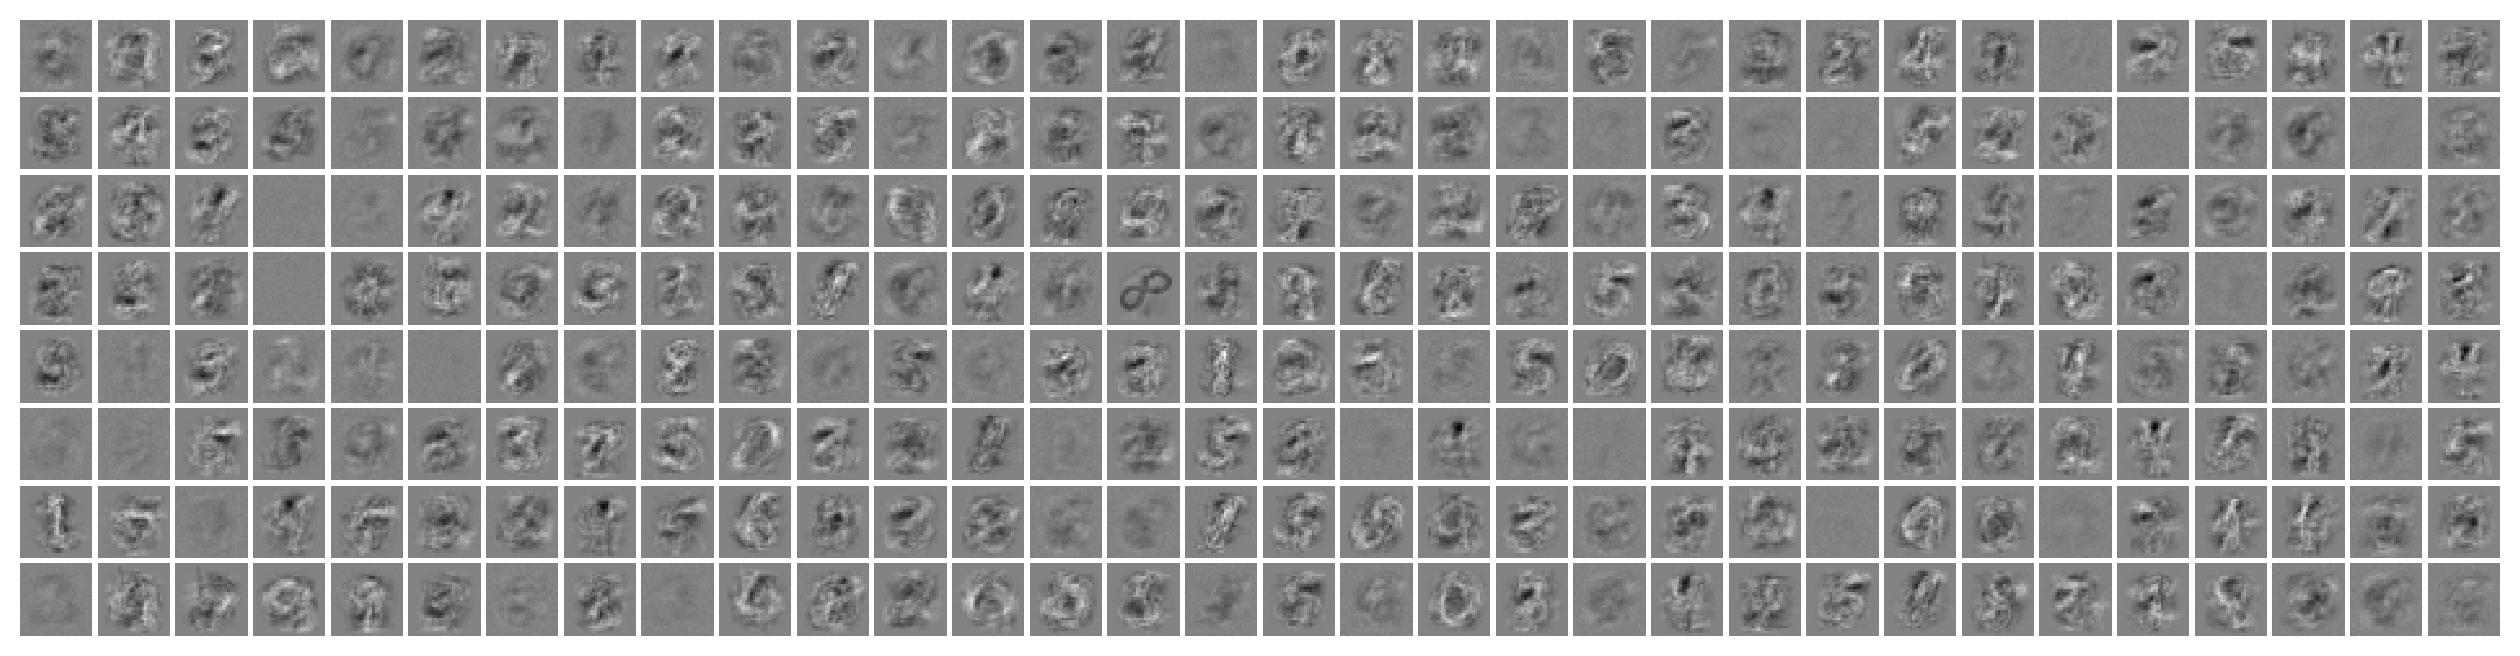

	layer 1: 2.00
	layer 2: 1.00
	layer 3: 4.00


In [18]:
mlp = [
    Layer(
        visible_size=VISIBLE_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        dropout_rate=0.0,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=2.0,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        dropout_rate=0.0,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=10,
        activation_fun=softmax,
        d_activation_fun=None,
        dropout_rate=0.0,
        learning_rate=SOFTMAX_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=4.0,
    ),
]

evaluate(
    mlp=mlp,
    train_set=mnist_train_images,
    train_labels=mnist_train_labels,
    validation_set=mnist_test_images,
    validation_labels=mnist_test_labels,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)

### MLP with dropout

Epoch 1:	########################################	elapsed: 2.30s, accuracy: 11.35
Epoch 2:	########################################	elapsed: 1.08s, accuracy: 11.35
Epoch 3:	########################################	elapsed: 0.68s, accuracy: 11.35
Epoch 4:	########################################	elapsed: 0.53s, accuracy: 11.35
Epoch 5:	########################################	elapsed: 0.44s, accuracy: 11.35
Epoch 6:	########################################	elapsed: 0.58s, accuracy: 82.57
Epoch 7:	########################################	elapsed: 0.59s, accuracy: 91.53
Epoch 8:	########################################	elapsed: 0.58s, accuracy: 91.69
Epoch 9:	########################################	elapsed: 0.51s, accuracy: 92.69
Epoch 10:	########################################	elapsed: 0.49s, accuracy: 94.03
Epoch 11:	########################################	elapsed: 0.80s, accuracy: 93.40
Epoch 12:	########################################	elapsed: 0.73s, accuracy: 94.82
Epoch 13:	###

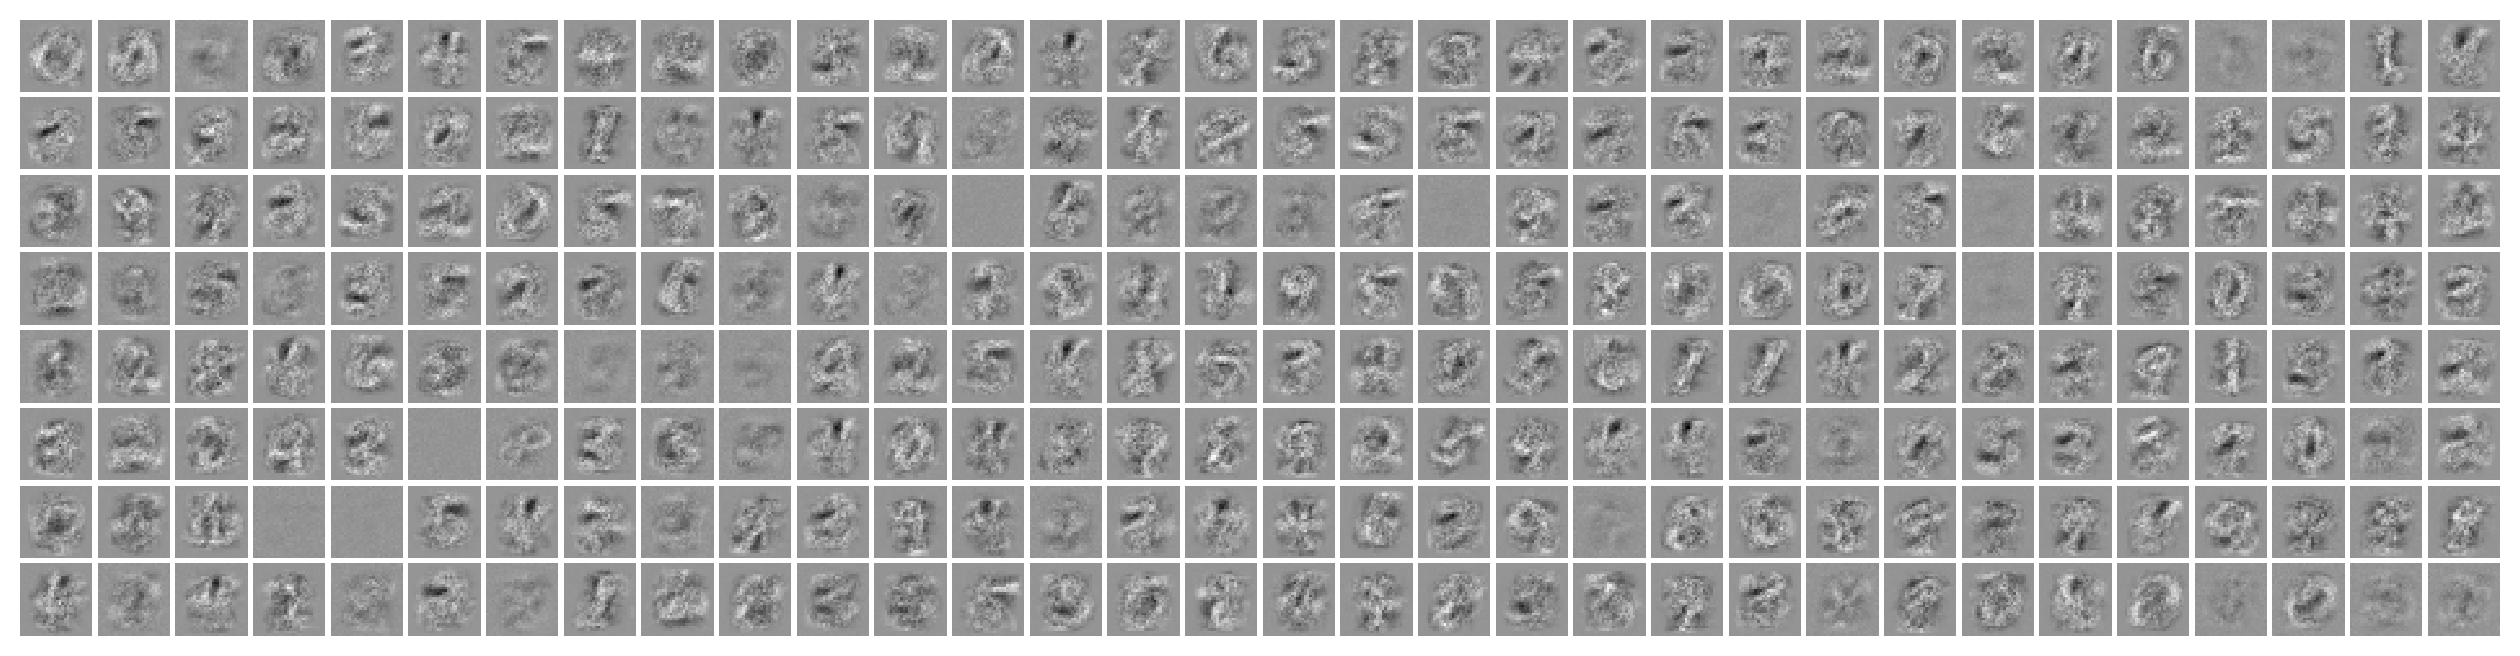

	layer 1: 2.00
	layer 2: 1.00
	layer 3: 4.00


In [19]:
mlp_with_dropout = [
    Layer(
        visible_size=VISIBLE_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        dropout_rate=0.2,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=2.0,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=relu,
        d_activation_fun=relu_derivative,
        dropout_rate=0.2,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=1.0,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=10,
        activation_fun=softmax,
        d_activation_fun=None,
        dropout_rate=0.5,
        learning_rate=SOFTMAX_LEARNING_RATE,
        momentum=MOMENTUM,
        weight_limit=4.0,
    ),
]

evaluate(
    mlp=mlp_with_dropout,
    train_set=mnist_train_images,
    train_labels=mnist_train_labels,
    validation_set=mnist_test_images,
    validation_labels=mnist_test_labels,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)